# Fine-tuning ModernBERT on GoEmotions
**Task:** Multi-label emotion classification (28 classes)  
**Model:** `answerdotai/ModernBERT-base`  

In [ ]:
# Install / upgrade all required packages
!pip install -q transformers datasets accelerate kagglehub scikit-learn seaborn

In [ ]:
# Confirm GPU is available
import torch
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


In [ ]:
# Core imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, f1_score, hamming_loss

from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    DataCollatorWithPadding,
)
import kagglehub

In [ ]:
# ── All hyperparameters in one place ─────────────────────────────────────────
MODEL_NAME  = "answerdotai/ModernBERT-base"
MAX_LENGTH  = 128       # GoEmotions comments are short, 128 is sufficient
BATCH_SIZE  = 32        # reduce to 16 if you get OOM errors
EPOCHS      = 5
LR          = 2e-5
THRESHOLD   = 0.5       # sigmoid cutoff for predicting a label as active
OUTPUT_DIR  = "./modernbert-goemotions"
SEED        = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

In [ ]:
# ── Download dataset from Kaggle and locate the data files ───────────────────
data_path = kagglehub.dataset_download("debarshichanda/goemotions")
print("Dataset root:", data_path)

# The TSV files live inside a 'data/' subdirectory
tsv_dir = os.path.join(data_path, "data")
print("Files in data/:", os.listdir(tsv_dir))

# TSV files have no header; columns are: text | label_ids | comment_id
def load_split(filename):
    df = pd.read_csv(
        os.path.join(tsv_dir, filename),
        sep="\t", header=None,
        names=["text", "labels", "comment_id"]
    )
    df["labels"] = df["labels"].apply(lambda x: [int(i) for i in str(x).split(",")])
    return df

train_df = load_split("train.tsv")
val_df   = load_split("dev.tsv")
test_df  = load_split("test.tsv")

print(f"Train: {len(train_df):,}  Val: {len(val_df):,}  Test: {len(test_df):,}")
train_df.head(3)

Using Colab cache for faster access to the 'goemotions' dataset.
Dataset root: /kaggle/input/goemotions
Files in data/: ['test.tsv', 'ekman_mapping.json', 'dev.tsv', 'emotions.txt', 'train.tsv', 'ekman_labels.csv', 'sentiment_dict.json', 'full_dataset', 'sentiment_mapping.json']
Train: 43,410  Val: 5,426  Test: 5,427


,text,labels,comment_id
0,My favourite food is anything I didn't have to...,[27],eebbqej
1,"Now if he does off himself, everyone will thin...",[27],ed00q6i
2,WHY THE FUCK IS BAYLESS ISOING,[2],eezlygj


In [ ]:
# ── Load the 28 emotion class names ──────────────────────────────────────────
with open(os.path.join(tsv_dir, "emotions.txt")) as f:
    emotion_labels = [line.strip() for line in f]

NUM_LABELS = len(emotion_labels)
print(f"{NUM_LABELS} classes:", emotion_labels)

28 classes: ['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']


/tmp/ipykernel_1715/2309979016.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=freq.index, y=freq.values, palette="viridis")


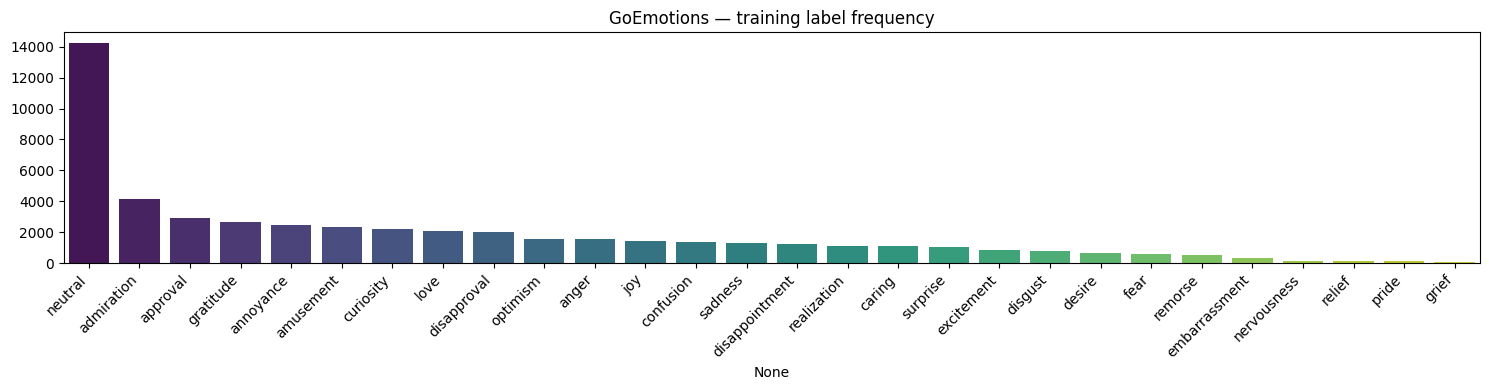

Avg labels per sample: 1.18


In [ ]:
# ── Quick EDA — label frequency + average labels per sample ──────────────────
counts = np.zeros(NUM_LABELS, dtype=int)
for row in train_df["labels"]:
    for idx in row:
        counts[idx] += 1

freq = pd.Series(counts, index=emotion_labels).sort_values(ascending=False)

plt.figure(figsize=(15, 4))
sns.barplot(x=freq.index, y=freq.values, palette="viridis")
plt.xticks(rotation=45, ha="right")
plt.title("GoEmotions — training label frequency")
plt.tight_layout()
plt.show()

avg = train_df["labels"].apply(len).mean()
print(f"Avg labels per sample: {avg:.2f}")

In [ ]:
# ── Convert label-index lists to multi-hot float vectors ─────────────────────
def to_multi_hot(label_lists, n):
    mat = np.zeros((len(label_lists), n), dtype=np.float32)
    for i, lbls in enumerate(label_lists):
        for l in lbls:
            mat[i, l] = 1.0
    return mat

train_labels = to_multi_hot(train_df["labels"], NUM_LABELS)
val_labels   = to_multi_hot(val_df["labels"],   NUM_LABELS)
test_labels  = to_multi_hot(test_df["labels"],  NUM_LABELS)

print("Label matrix shape (train):", train_labels.shape)

Label matrix shape (train): (43410, 28)


In [ ]:
# ── Tokenise all splits — padding is handled dynamically by the data collator ─
print(f"Loading tokenizer: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(texts):
    return tokenizer(list(texts), truncation=True, max_length=MAX_LENGTH, padding=False)

train_enc = tokenize(train_df["text"])
val_enc   = tokenize(val_df["text"])
test_enc  = tokenize(test_df["text"])
print("Tokenisation complete.")

Loading tokenizer: answerdotai/ModernBERT-base


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

Tokenisation complete.


In [ ]:
# ── PyTorch Dataset wrapper ───────────────────────────────────────────────────
class EmotionDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels    = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = self.labels[idx]
        return item

train_dataset = EmotionDataset(train_enc, train_labels)
val_dataset   = EmotionDataset(val_enc,   val_labels)
test_dataset  = EmotionDataset(test_enc,  test_labels)
print(f"Dataset sizes — train: {len(train_dataset):,}, val: {len(val_dataset):,}, test: {len(test_dataset):,}")

Dataset sizes — train: 43,410, val: 5,426, test: 5,427


In [ ]:
# ── Load ModernBERT with a 28-class head ──────────────────────────────────────
# problem_type="multi_label_classification" makes the Trainer use BCEWithLogitsLoss
print(f"Loading model: {MODEL_NAME}")
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    problem_type="multi_label_classification",
)
model.to(DEVICE)

total     = sum(p.numel() for p in model.parameters()) / 1e6
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6
print(f"Total params: {total:.1f}M  |  Trainable: {trainable:.1f}M")

Loading model: answerdotai/ModernBERT-base


model.safetensors:   0%|          | 0.00/599M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.bias   | MISSING    | 
classifier.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total params: 149.6M  |  Trainable: 149.6M


In [ ]:
# ── Metrics reported after each epoch ────────────────────────────────────────
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = torch.sigmoid(torch.tensor(logits)).numpy()
    preds = (probs >= THRESHOLD).astype(int)
    return {
        "micro_f1":     f1_score(labels, preds, average="micro",  zero_division=0),
        "macro_f1":     f1_score(labels, preds, average="macro",  zero_division=0),
        "hamming_loss": hamming_loss(labels, preds),
    }

In [ ]:
# ── Training configuration ────────────────────────────────────────────────────
training_args = TrainingArguments(
    output_dir                  = OUTPUT_DIR,
    num_train_epochs            = EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE,
    learning_rate               = LR,
    weight_decay                = 0.01,
    warmup_ratio                = 0.1,
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    metric_for_best_model       = "micro_f1",
    greater_is_better           = True,
    logging_steps               = 100,
    fp16                        = True,   # AMP for faster GPU training
    seed                        = SEED,
    report_to                   = "none",
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [ ]:
# ── Build the Trainer and start fine-tuning ───────────────────────────────────
trainer = Trainer(
    model              = model,
    args               = training_args,
    train_dataset      = train_dataset,
    eval_dataset       = val_dataset,
    processing_class   = tokenizer,
    data_collator      = DataCollatorWithPadding(tokenizer),
    compute_metrics    = compute_metrics,
    callbacks          = [EarlyStoppingCallback(early_stopping_patience=2)],
)

trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': None, 'bos_token_id': None}.
W0521 14:33:15.625000 1715 torch/_inductor/utils.py:1679] [1/0_1] Not enough SMs to use max_autotune_gemm mode


Epoch,Training Loss,Validation Loss,Micro F1,Macro F1,Hamming Loss,Runtime,Samples Per Second,Steps Per Second
1,0.090978,0.087562,0.556601,0.375507,0.030705,10.535300,515.030000,16.136000
2,0.080166,0.082227,0.583584,0.452763,0.029185,6.756500,803.075000,25.161000
3,0.069311,0.083731,0.584995,0.455846,0.030146,7.111800,762.958000,23.904000
4,0.058147,0.087492,0.576122,0.472938,0.031081,7.154000,758.455000,23.763000
5,0.044374,0.091803,0.574058,0.473207,0.031686,7.016500,773.321000,24.229000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=6785, training_loss=0.0794319451162722, metrics={'train_runtime': 1134.8873, 'train_samples_per_second': 191.252, 'train_steps_per_second': 5.979, 'total_flos': 5254989774832368.0, 'train_loss': 0.0794319451162722, 'epoch': 5.0})

In [ ]:
# ── Full evaluation on the held-out test set ─────────────────────────────────
predictions = trainer.predict(test_dataset)
probs = torch.sigmoid(torch.tensor(predictions.predictions)).numpy()
preds = (probs >= THRESHOLD).astype(int)

print(classification_report(test_labels, preds, target_names=emotion_labels, zero_division=0))
print(f"Micro-F1     : {f1_score(test_labels, preds, average='micro',  zero_division=0):.4f}")
print(f"Macro-F1     : {f1_score(test_labels, preds, average='macro',  zero_division=0):.4f}")
print(f"Hamming Loss : {hamming_loss(test_labels, preds):.4f}")

                precision    recall  f1-score   support

    admiration       0.76      0.60      0.67       504
     amusement       0.78      0.82      0.80       264
         anger       0.59      0.12      0.19       198
     annoyance       0.53      0.14      0.22       320
      approval       0.60      0.28      0.38       351
        caring       0.54      0.27      0.36       135
     confusion       0.59      0.33      0.42       153
     curiosity       0.55      0.40      0.47       284
        desire       0.56      0.23      0.32        83
disappointment       0.54      0.09      0.16       151
   disapproval       0.48      0.29      0.36       267
       disgust       0.73      0.28      0.41       123
 embarrassment       0.82      0.24      0.38        37
    excitement       0.58      0.27      0.37       103
          fear       0.71      0.58      0.64        78
     gratitude       0.96      0.88      0.92       352
         grief       0.00      0.00      0.00  

/tmp/ipykernel_1715/1333199908.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=f1_series.index, y=f1_series.values, palette="magma")


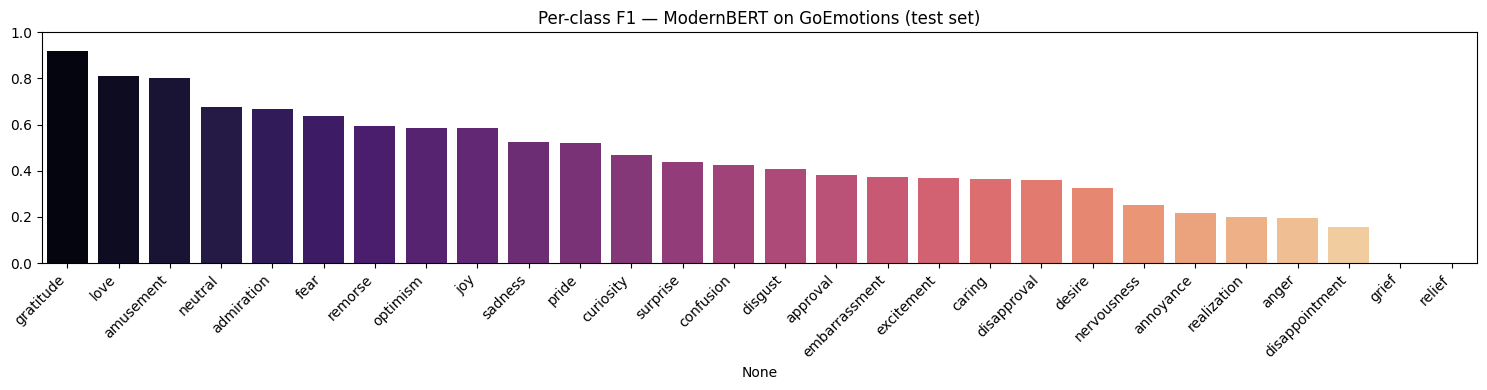

In [ ]:
# ── Per-class F1 bar chart ────────────────────────────────────────────────────
report = classification_report(
    test_labels, preds, target_names=emotion_labels,
    zero_division=0, output_dict=True
)
f1_series = pd.Series(
    {lbl: report[lbl]["f1-score"] for lbl in emotion_labels}
).sort_values(ascending=False)

plt.figure(figsize=(15, 4))
sns.barplot(x=f1_series.index, y=f1_series.values, palette="magma")
plt.xticks(rotation=45, ha="right")
plt.title("Per-class F1 — ModernBERT on GoEmotions (test set)")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [ ]:
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print(f"Model saved to {OUTPUT_DIR}/")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to ./modernbert-goemotions/
